In [6]:
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
from astropy.visualization import simple_norm
from spectral_cube import SpectralCube
import regions
from regions import Regions
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.visualization.wcsaxes import add_scalebar
import cv2

# Cloud C

In [2]:
hpg = True

if hpg:
    basepath_jwst = '/orange/adamginsburg/jwst/cloudc/images/'
    basepath_glimpse = '/orange/adamginsburg/cmz/glimpse_data/'
    fn_cont_B3 = '/orange/adamginsburg/jwst/cloudc/alma/ACES/uid___A001_X15a0_X1a8.s36_0.Sgr_A_star_sci.spw33_35.cont.I.iter1.image.tt0'
    fn_cont_B6 = ''
else:
    basepath_jwst = '/home/savannahgramze/research/Research/JWST/cloudc/images/'
    basepath_glimpse = '/home/savannahgramze/research/Research/glimpse/'

fn_405 = f'{basepath_jwst}/jw02221-o002_t001_nircam_clear-f405n-merged_i2d.fits'#F405_reproj_merged-fortricolor.fits'
fn_410 = f'{basepath_jwst}/jw02221-o002_t001_nircam_clear-f410m-merged_i2d.fits'#F410_reproj_merged-fortricolor.fits'
fn_466 = f'{basepath_jwst}/jw02221-o002_t001_nircam_clear-f466n-merged_i2d.fits'#F466_reproj_merged-fortricolor.fits'
fn_187 = f'{basepath_jwst}/F187_reproj_merged-fortricolor.fits'
fn_182 = f'{basepath_jwst}/F182_reproj_merged-fortricolor.fits'
fn_212 = f'{basepath_jwst}/F212_reproj_merged-fortricolor.fits'

In [3]:
pos = SkyCoord('17:46:20.6290029866', '-28:37:49.5114204513', unit=(u.hour, u.deg))
l = 113.8*u.arcsec
w = 3.3*u.arcmin
reg = regions.RectangleSkyRegion(pos, width=l, height=w)

In [4]:
def get405():
    return fits.open(fn_405)['SCI']

def get410():
    return fits.open(fn_410)['SCI']

def get466():
    return fits.open(fn_466)['SCI']

def get_rgb():
    cutout_R = get466()
    cutout_B = get405()
    cutout_G = cutout_R.data + cutout_B.data

    rgb = np.array(
        [
            cutout_R.data,
            cutout_G,
            cutout_B.data
        ]
    ).swapaxes(0,2).swapaxes(0,1)

    rgb[rgb <= 0] = np.nan

    rgb_scaled = np.array([
        simple_norm(rgb[:,:,0], stretch='asinh', vmin=-1, vmax=90)(rgb[:,:,0]),
        simple_norm(rgb[:,:,1], stretch='asinh', vmin=-2, vmax=210)(rgb[:,:,1]),
        simple_norm(rgb[:,:,2], stretch='asinh', vmin=-1, vmax=120)(rgb[:,:,2]),
    ]).swapaxes(0,2)

    return rgb_scaled.swapaxes(0,1), WCS(cutout_R.header)

In [7]:
img, ww = get_rgb()

img = (img*256)
img[img<0] = 0
img[img>255] = 255

mask_0 = np.logical_and(img[:,:,0]==0, img[:,:,1]==0, img[:,:,2]==0)
mask_nan = np.logical_and(np.isnan(img[:,:,0]), np.isnan(img[:,:,1]), np.isnan(img[:,:,2]))
mask = np.logical_or(mask_0, mask_nan)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
dilate = cv2.dilate(mask.astype('uint8'), kernel, iterations=1)
mask = np.array(dilate, dtype=bool)

img = np.append(img, np.array([~mask]).swapaxes(0,2).swapaxes(0,1)*255, axis=2)
img = img.astype('uint8')

/scratch/local/31455051/ipykernel_3670175/1006375100.py:15: RuntimeWarning: invalid value encountered in cast
  img = img.astype('uint8')


In [12]:
reg_f = Regions.read('/orange/adamginsburg/jwst/cloudc/lactea-filament/lactea-filament/regions_/filament_short.region')
reg_b = Regions.read('/orange/adamginsburg/jwst/cloudc/lactea-filament/lactea-filament/regions_/cloudb.region')
reg_c1 = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/cloudc1_ice.reg')
reg_c2 = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/cloudc2_ice.reg')
reg_d = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/cloudd_ice.reg')
reg_fil_r = Regions.read('/orange/adamginsburg/jwst/cloudc/lactea-filament/lactea-filament/regions_/filament_right.region')
reg_left_cd = Regions.read('/orange/adamginsburg/jwst/cloudc/lactea-filament/lactea-filament/regions_/left_cloudd.region')
reg_c_n = Regions.read('/orange/adamginsburg/jwst/cloudc/lactea-filament/lactea-filament/regions_/cloudc_north.region')
reg_c_s = Regions.read('/orange/adamginsburg/jwst/cloudc/lactea-filament/lactea-filament/regions_/cloudc_south.region')

#regions_cloudc = [reg_f, reg_c1, reg_c2, reg_d, reg_fil_r, reg_left_cd, reg_c_n, reg_c_s]
regions_cloudc = [reg_f, reg_c1, reg_c2, reg_d, reg_b, reg_fil_r, reg_left_cd, reg_c_n, reg_c_s]
colors_cloudc = ['k', 'r', 'g', 'b', 'orange', 'magenta', 'white', 'cyan', 'purple']


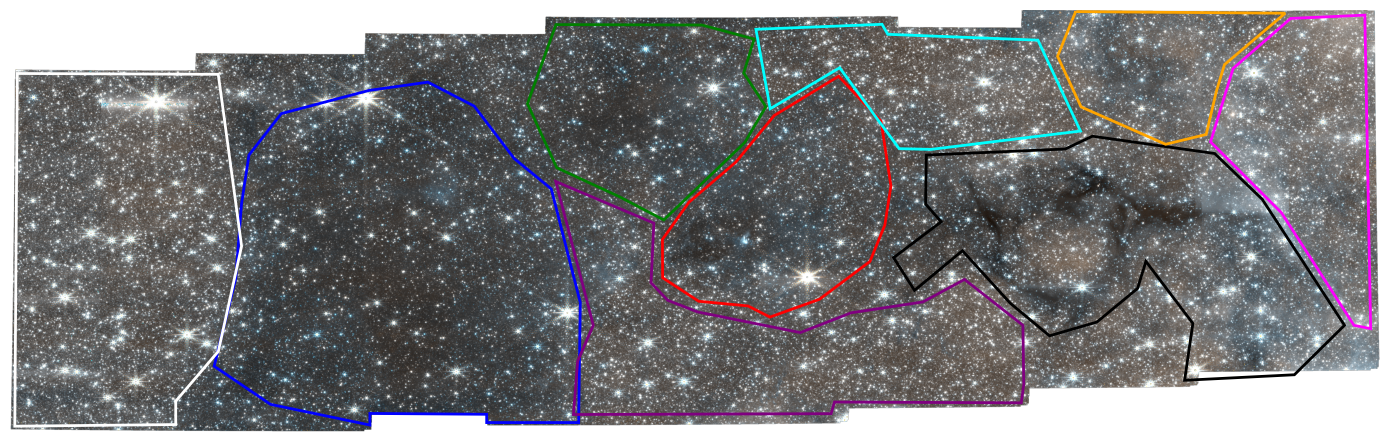

In [16]:
fig = plt.figure(figsize=(14,7))
ax = plt.subplot(projection=ww)
ax.imshow(img, origin='lower')
#reg_f[0].to_pixel(ww).plot(ax=ax, edgecolor='cyan', facecolor='none', lw=2, label='Filament')
#reg_c1[0].to_pixel(ww).plot(ax=ax, edgecolor='magenta', facecolor='none', lw=2, label='Cloud C1')
#reg_c2[0].to_pixel(ww).plot(ax=ax, edgecolor='yellow', facecolor='none', lw=2, label='Cloud C2')
#reg_d[0].to_pixel(ww).plot(ax=ax, edgecolor='red', facecolor='none', lw=2, label='Cloud D')

for i in range(9):
    regions_cloudc[i][0].to_pixel(ww).plot(ax=ax, edgecolor=colors_cloudc[i], facecolor='none', lw=2)#, label=f'Region {i+1}')

dec = ax.coords[1]
ra = ax.coords[0]
dec.set_ticks_position('b')
dec.set_ticklabel_position('b')
dec.set_axislabel_position('b')
dec.set_ticklabel(size=14)
ra.set_ticks_position('l')
ra.set_ticklabel_position('l')
ra.set_axislabel_position('l')
ra.set_ticklabel(size=14)

ax.set_ylabel('Right Ascension', fontsize=16)
ax.set_xlabel('Declination', fontsize=16)
ax.set_axis_off()

plt.tight_layout()

plt.savefig('/orange/adamginsburg/jwst/cloudc/figures/three_color_regions_cloudc.png', dpi=300, bbox_inches='tight', transparent=True)

# Brick

In [26]:
hpg = True

if hpg:
    basepath_jwst_brick = '/orange/adamginsburg/jwst/brick/images/'
    basepath_glimpse = '/orange/adamginsburg/cmz/glimpse_data/'
    #fn_cont_B3 = '/orange/adamginsburg/jwst/cloudc/alma/ACES/uid___A001_X15a0_X1a8.s36_0.Sgr_A_star_sci.spw33_35.cont.I.iter1.image.tt0'
    #fn_cont_B6 = ''

fn_405 = f'{basepath_jwst_brick}/jw02221-o001_t001_nircam_clear-f405n-merged-reproject_i2d.fits'#F405_reproj_merged-fortricolor.fits'
fn_410 = f'{basepath_jwst_brick}/jw02221-o001_t001_nircam_clear-f410m-merged-reproject_i2d.fits'#F410_reproj_merged-fortricolor.fits'
fn_466 = f'{basepath_jwst_brick}/jw02221-o001_t001_nircam_clear-f466n-merged-reproject_i2d.fits'#F466_reproj_merged-fortricolor.fits'
# jw02221-o001_t001_nircam_clear-f466n-merged-reproject_i2d.fits
fn_187 = f'{basepath_jwst_brick}/F187_reproj_merged-fortricolor.fits'
fn_182 = f'{basepath_jwst_brick}/F182_reproj_merged-fortricolor.fits'
fn_212 = f'{basepath_jwst_brick}/F212_reproj_merged-fortricolor.fits'

In [36]:
def get405():
    return fits.open(fn_405)['SCI']

def get410():
    return fits.open(fn_410)['SCI']

def get466():
    return fits.open(fn_466)['SCI']

def get_rgb():
    cutout = get466()
    cutout_R = get466().data
    cutout_B = get405().data[:,:-1]
    cutout_G = cutout_R + cutout_B

    rgb = np.array(
        [
            cutout_R.data,
            cutout_G,
            cutout_B.data
        ]
    ).swapaxes(0,2).swapaxes(0,1)

    rgb[rgb <= 0] = np.nan

    rgb_scaled = np.array([
        simple_norm(rgb[:,:,0], stretch='asinh', vmin=-1, vmax=90)(rgb[:,:,0]),
        simple_norm(rgb[:,:,1], stretch='asinh', vmin=-2, vmax=210)(rgb[:,:,1]),
        simple_norm(rgb[:,:,2], stretch='asinh', vmin=-1, vmax=120)(rgb[:,:,2]),
    ]).swapaxes(0,2)

    return rgb_scaled.swapaxes(0,1), WCS(cutout.header)

In [37]:
img, ww = get_rgb()

img = (img*256)
img[img<0] = 0
img[img>255] = 255

mask_0 = np.logical_and(img[:,:,0]==0, img[:,:,1]==0, img[:,:,2]==0)
mask_nan = np.logical_and(np.isnan(img[:,:,0]), np.isnan(img[:,:,1]), np.isnan(img[:,:,2]))
mask = np.logical_or(mask_0, mask_nan)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
dilate = cv2.dilate(mask.astype('uint8'), kernel, iterations=1)
mask = np.array(dilate, dtype=bool)

img = np.append(img, np.array([~mask]).swapaxes(0,2).swapaxes(0,1)*255, axis=2)
img = img.astype('uint8')

/scratch/local/31455051/ipykernel_3670175/1006375100.py:15: RuntimeWarning: invalid value encountered in cast
  img = img.astype('uint8')


In [38]:
reg_brick_north = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_north.reg')
reg_brick_south = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_south.reg')
reg_brick_head = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_head.reg')
reg_brick_sfluff = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfluff.reg')
reg_brick_nfluff = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_nfluff.reg')
reg_brick_sfr = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfr_tight.reg')
reg_brick_sfrwide = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfr.reg')
reg_brick_punch = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_punch.reg')
reg_brick_sfore = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfore.reg')
reg_brick_nclear = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_nclear.reg')
reg_brick_topc = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_topc.reg')

regions_brick = [reg_brick_north, reg_brick_south, reg_brick_head, reg_brick_sfluff, reg_brick_nfluff, reg_brick_sfr, reg_brick_sfrwide, reg_brick_punch, reg_brick_sfore, reg_brick_nclear, reg_brick_topc]
colors_brick = ['red', 'blue', 'green', 'cyan', 'magenta', 'purple', 'brown', 'orange', 'pink', 'k', 'gray']

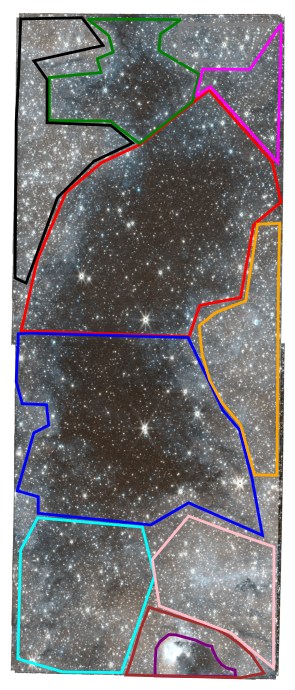

In [40]:
fig = plt.figure(figsize=(14,7))
ax = plt.subplot(projection=ww)
ax.imshow(img, origin='lower')
#reg_f[0].to_pixel(ww).plot(ax=ax, edgecolor='cyan', facecolor='none', lw=2, label='Filament')
#reg_c1[0].to_pixel(ww).plot(ax=ax, edgecolor='magenta', facecolor='none', lw=2, label='Cloud C1')
#reg_c2[0].to_pixel(ww).plot(ax=ax, edgecolor='yellow', facecolor='none', lw=2, label='Cloud C2')
#reg_d[0].to_pixel(ww).plot(ax=ax, edgecolor='red', facecolor='none', lw=2, label='Cloud D')

for i in range(11):
    regions_brick[i][0].to_pixel(ww).plot(ax=ax, edgecolor=colors_brick[i], facecolor='none', lw=2)#, label=f'Region {i+1}')

dec = ax.coords[1]
ra = ax.coords[0]
dec.set_ticks_position('b')
dec.set_ticklabel_position('b')
dec.set_axislabel_position('b')
dec.set_ticklabel(size=14)
ra.set_ticks_position('l')
ra.set_ticklabel_position('l')
ra.set_axislabel_position('l')
ra.set_ticklabel(size=14)

ax.set_ylabel('Right Ascension', fontsize=16)
ax.set_xlabel('Declination', fontsize=16)
ax.set_axis_off()

plt.tight_layout()

plt.savefig('/orange/adamginsburg/jwst/cloudc/figures/three_color_regions_brick.png', dpi=300, bbox_inches='tight', transparent=True)